## шаг 1

Вы работаете в интернет-магазине «Стримчик», который продаёт по всему миру компьютерные игры. Из открытых источников доступны исторические данные о продажах игр, оценки пользователей и экспертов, жанры и платформы (например, Xbox или PlayStation). Вам нужно выявить определяющие успешность игры закономерности. Это позволит сделать ставку на потенциально популярный продукт и спланировать рекламные кампании.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import os
from scipy import stats as st
from sklearn import datasets
import seaborn as sns
import altair as alt

In [2]:
pth1 = '/Users/ikashkovskiy/Desktop/YANDEX P/data/strimchik/games.csv' 
pth2 = '/datasets/games.csv'

if os.path.exists(pth1):
    df = pd.read_csv(pth1)
elif os.path.exists(pth2):
    df = pd.read_csv(pth2)
else:
    print('Something is wrong')

## шаг 2

In [3]:
#df.info()

In [4]:
df.columns = df.columns.str.lower()
#приводим к нижнему регистру

In [5]:
#проверяем пропущенные значения
# в name, genre и year_of_release нужно убрать пропуски для более информативной статистики
display(df.isna().sum())

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         6701
rating             6766
dtype: int64

In [6]:
df[df['name'].isnull()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
659,NaN,GEN,1993.0,NaN,1.78,0.53,0.00,0.08,NaN,NaN,NaN
14244,NaN,GEN,1993.0,NaN,0.00,0.00,0.03,0.00,NaN,NaN,NaN


In [7]:
df[df['genre'].isnull()]
#2 игры без названия и жанра, заменим на "unknown" что бы не удалять

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
659,NaN,GEN,1993.0,NaN,1.78,0.53,0.00,0.08,NaN,NaN,NaN
14244,NaN,GEN,1993.0,NaN,0.00,0.00,0.03,0.00,NaN,NaN,NaN


In [8]:
df.fillna({"name" : "unknown", "genre" : "unknown"}, inplace=True)
#оставим для статистики платформы

In [9]:
#заменим пропуски в годах на среднее по платформе
mean_year_release=df.groupby('platform')['year_of_release'].transform('mean')
df['year_of_release'].fillna(mean_year_release,inplace=True)
#округляем
df['year_of_release'] = np.ceil(df['year_of_release'])
#df[df['year_of_release'].isnull()]

In [10]:
df['user_score'].sort_values().unique()
#tbd = to be decided or to be determined: used when something has not yet been decided or is not yet known
#рейтинг еще не определен, заполним NAN
df['user_score'] = df['user_score'].replace("tbd", np.NaN)

In [11]:
df = df.astype({'year_of_release': np.int64, 'user_score': 'float64'})

In [12]:
#добавляем столбец с суммой продаж
df['total_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales']

In [13]:
mean_user_score=df.groupby('total_sales')['user_score'].transform('mean')
df['user_score'].fillna(mean_user_score,inplace=True)
#df[df['user_score'].isnull()]

In [14]:
mean_user_score=df.groupby('platform')['user_score'].transform('mean')
df['user_score'].fillna(mean_user_score,inplace=True)
df[df['user_score'].isnull()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales


In [15]:
mean_user_score=df.groupby('total_sales')['critic_score'].transform('mean')
df['critic_score'].fillna(mean_user_score,inplace=True)
#df[df['critic_score'].isnull()]

In [16]:
mean_user_score=df.groupby('platform')['critic_score'].transform('mean')
df['critic_score'].fillna(mean_user_score,inplace=True)
df[df['critic_score'].isnull()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales


In [17]:
#проверяем на дубликаты
df.duplicated().sum()

0

## итоги по шагу 2


 #### подготовил данные:
 - заменил пропуски в столбце year_of_release на медиану по платформе (удалялть более 250 строк нецелесообразно)
 - сменил типы данных у двух стодбцов для упрощения дальнейщего анализа
 - добавил столбец с суммой продаж по регионам
 - привел названия столбцов к нижнему регистру
 - заменил пропушенные значения оценок критиков и пользователей медианами в зависимости от платформы  и продаж

## шаг 3

In [18]:
#таблица с количеством игр по платформам и годам, не очень информативная
df_game_sum = (df.pivot_table(index=[ 'platform','year_of_release'],
                             values=['name'],
                             aggfunc = {'name':'count'}))

df_game_sum

name
platform year_of_release      
2600     1980                9
         1981               46
         1982               36
         1983               28
         1984                1
...                        ...
XB       2008                1
XOne     2013               19
         2014               61
         2015               80
         2016               87

[238 rows x 1 columns]

Text(133.0, 0.5, 'Платформы')

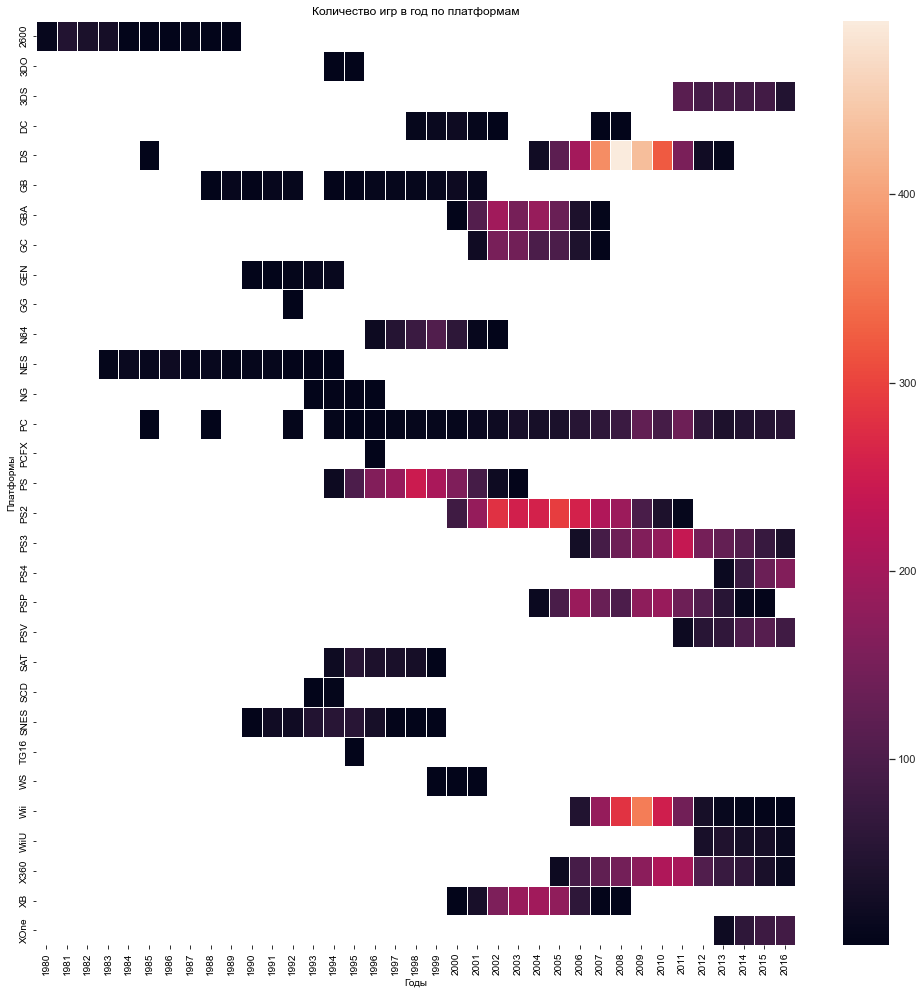

In [19]:
#построим тепловую карту для определния жизненого цикла платформ 
df_heatmap=df.pivot_table(index="platform",columns='year_of_release',values='name',
                             aggfunc = {'name':'count'})
f, ax = plt.subplots(figsize=(17,17))
sns.set_theme()
sns.heatmap(df_heatmap, linewidths=.5)
plt.title("Количество игр в год по платформам")
plt.xlabel("Годы")
plt.ylabel("Платформы")

 - По данным тепловой карты можно сделать вывод, о том что платформы (кроме ПК) обычно являются популярными около 10 лет, далее их заменяет более продвинутая модель (прим. XB - XB360 - XOne или PS - PS2 - PS3 - PS4)
 - Так же видно количество игр выпущенных для различных платформ

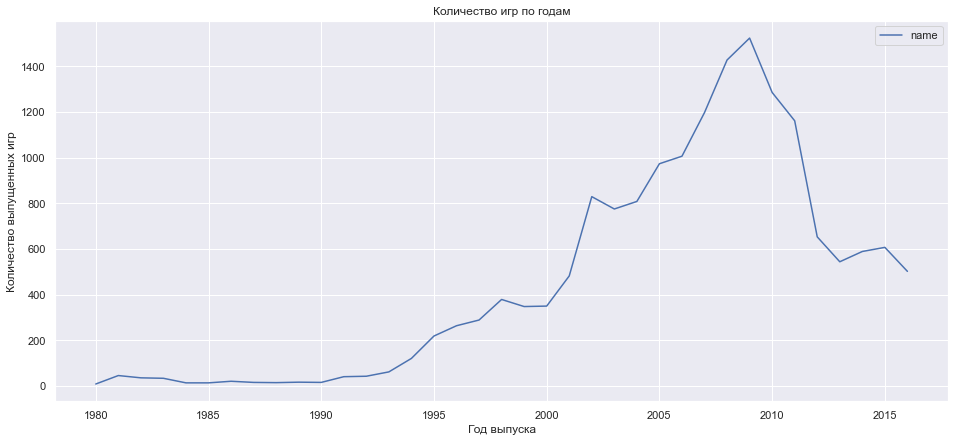

In [20]:
#график выхода игр по годам для всех платформ
#видно что после 2000 года начался резкий рост производства игр
df.pivot_table(index='year_of_release', values='name', aggfunc={'name':'count'}).plot(grid=True, figsize=(16, 7))
plt.title("Количество игр по годам")
plt.xlabel("Год выпуска")
plt.ylabel("Количество выпущенных игр")
plt.legend()

 - Рост выпуск игр начался в 2000х годах, пик пришелся на 2009, далее наметился спад

In [21]:
#список 5 самых прибыльных платформ
platforms_top = df.groupby('platform')['total_sales'].sum().sort_values()[-5:].index.tolist()
platforms_top

['DS', 'Wii', 'PS3', 'X360', 'PS2']

 - Проверим данные для основных платформ 

In [22]:
df_top_platform_after_2000 = df.query('platform == @platforms_top and year_of_release > 2000')

Text(129.5, 0.5, 'Платформы')

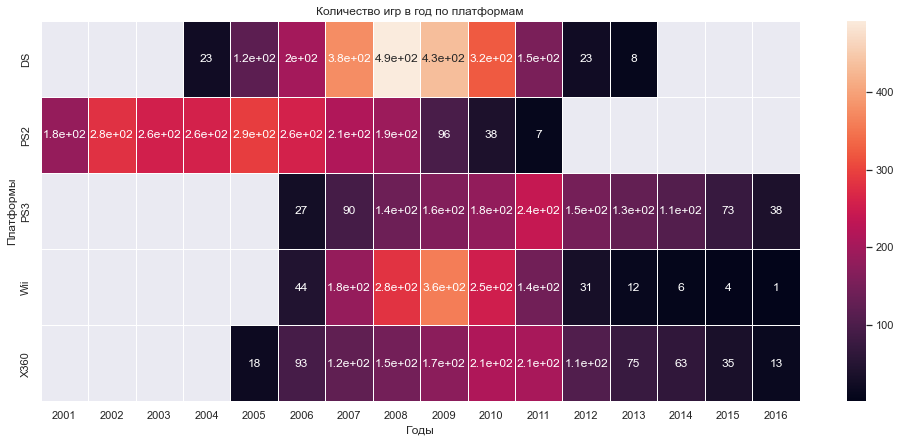

In [23]:
df_heatmap=df_top_platform_after_2000.pivot_table(index="platform",columns='year_of_release',values='name',
                             aggfunc = {'name':'count'})
f, ax = plt.subplots(figsize=(17,7))
sns.set_theme()
sns.heatmap(df_heatmap, linewidths=.5, annot=True)
plt.title("Количество игр в год по платформам")
plt.xlabel("Годы")
plt.ylabel("Платформы")

Text(129.5, 0.5, 'Платформы')

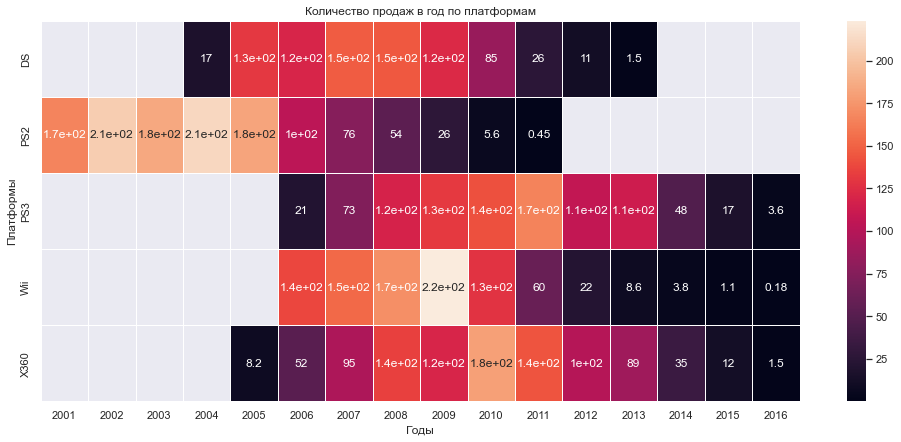

In [24]:
df_heatmap=df_top_platform_after_2000.pivot_table(index="platform",columns='year_of_release',values='total_sales',
                             aggfunc = {'total_sales':sum})
f, ax = plt.subplots(figsize=(17,7))
sns.set_theme()
sns.heatmap(df_heatmap, linewidths=.5, annot=True)
plt.title("Количество продаж в год по платформам")
plt.xlabel("Годы")
plt.ylabel("Платформы")

 - срез по платформам, которые были актуальны в предыдущие 16 лет, но если брать в расчет то что платформа "живет" около 10 лет, то их из анализа стоит убрать

In [25]:
#срез по платформам, которые возможно будут актуальны в будушем
df_platform_after_2005 = df.query('platform != @platforms_top and year_of_release > 2009')

Text(129.5, 0.5, 'Платформы')

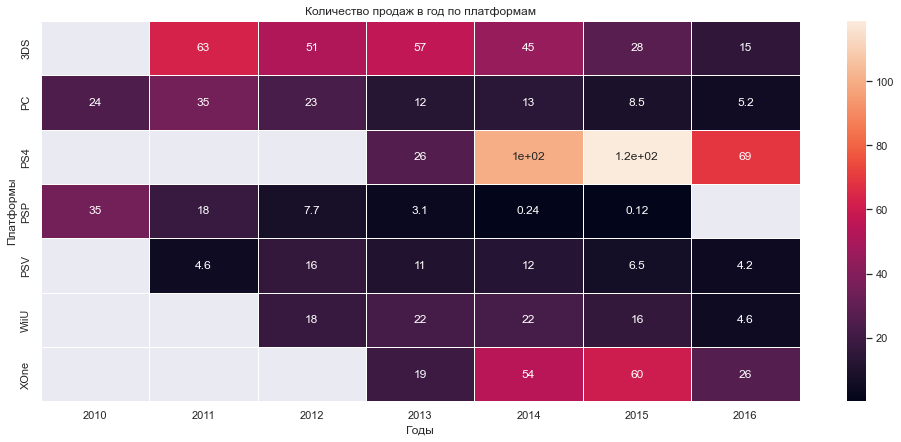

In [26]:
df_heatmap=df_platform_after_2005.pivot_table(index="platform",columns='year_of_release',values='total_sales',
                             aggfunc = {'total_sales':sum})
f, ax = plt.subplots(figsize=(17,7))
sns.set_theme()
sns.heatmap(df_heatmap, linewidths=.5, annot=True)
plt.title("Количество продаж в год по платформам")
plt.xlabel("Годы")
plt.ylabel("Платформы")

Text(129.5, 0.5, 'Платформы')

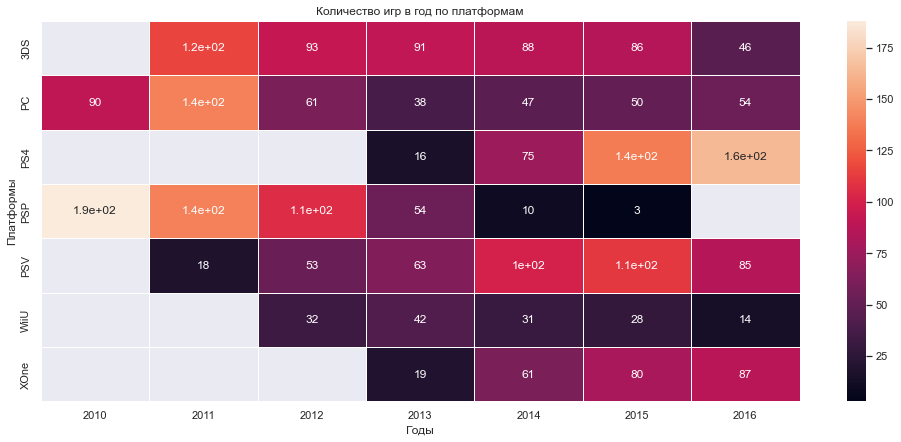

In [27]:
df_heatmap=df_platform_after_2005.pivot_table(index="platform",columns='year_of_release',values='name',
                             aggfunc = {'name':'count'})
f, ax = plt.subplots(figsize=(17,7))
sns.set_theme()
sns.heatmap(df_heatmap, linewidths=.5, annot=True)
plt.title("Количество игр в год по платформам")
plt.xlabel("Годы")
plt.ylabel("Платформы")

Text(0, 0.5, 'Количество продаж')

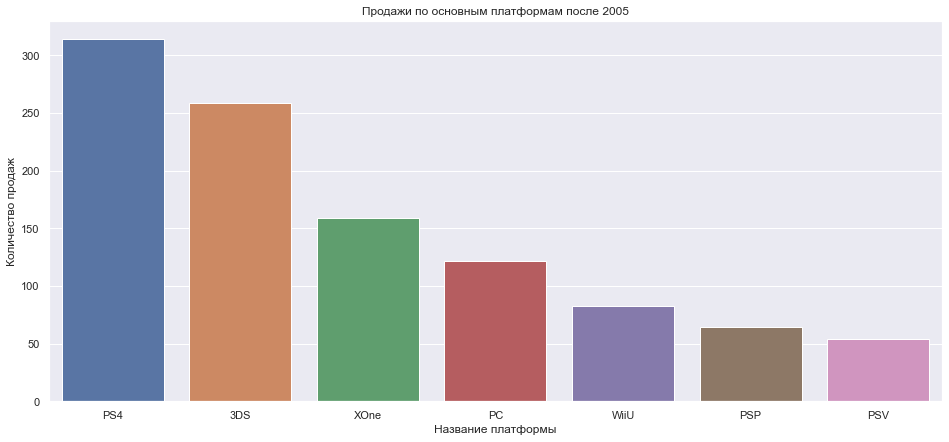

In [28]:
sales_on_platform = df_platform_after_2005.pivot_table(index='platform', values='total_sales', aggfunc='sum').sort_values(
    by='total_sales', ascending=False)

plt.figure(figsize=(16,7))
sns.barplot(x=sales_on_platform.index, y=sales_on_platform['total_sales'])
plt.title("Продажи по основным платформам после 2005")
plt.xlabel("Название платформы")
plt.ylabel("Количество продаж")

In [29]:
#sales_on_platform.head()

Text(0, 0.5, 'Количество продаж')

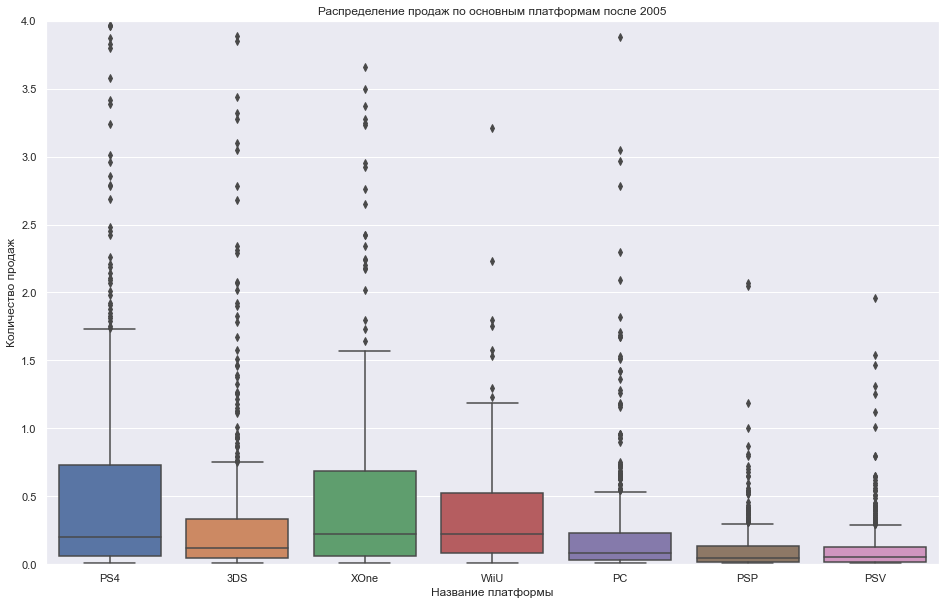

In [30]:
#Постройте график «ящик с усами» по глобальным продажам игр в разбивке по платформам. Опишите результат.
plt.figure(figsize=(16,10))
plt.ylim(0,4)
sns.boxplot(x='platform',y='total_sales',data=df_platform_after_2005)
plt.title("Распределение продаж по основным платформам после 2005")
plt.xlabel("Название платформы")
plt.ylabel("Количество продаж")

 - медианы на стационарных консолях схожи, медианы на портативных консолях так же схожи. Продажи на ПК низкие скорее всего потому что для ПК делают мало игр. 
 - Все диаграммы скошены вправо 
 

In [31]:
#создадим отдельный датафрейм для анализа корреляции
df_ps3 = df.query('platform == "PS3"')
#df_ps3

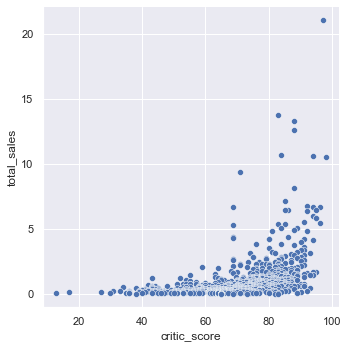

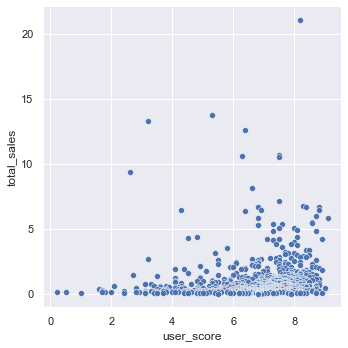

In [32]:
sns.relplot(x="critic_score", y="total_sales", data=df_ps3)
sns.relplot(x="user_score", y="total_sales", data=df_ps3)

In [33]:
print('корреляция отзывов критиков и продаж равна =', df['total_sales'].corr(df['critic_score']))
print('корреляция отзывов пользователей и продаж равна =', df['total_sales'].corr(df['user_score']))

корреляция отзывов критиков и продаж равна = 0.26464109138171166
корреляция отзывов пользователей и продаж равна = 0.10593979423809687


In [34]:
print('корреляция отзывов критиков и продаж на платформе PS3 равна =', df_ps3['total_sales'].corr(df_ps3['critic_score']))
print('корреляция отзывов пользователей и продаж на платформе PS3 равна =', df_ps3['total_sales'].corr(df_ps3['user_score']))

корреляция отзывов критиков и продаж на платформе PS3 равна = 0.4611161868404511
корреляция отзывов пользователей и продаж на платформе PS3 равна = 0.10335255887286397


 - Корреляция продаж и отзывов критиков заметно выше чем зависимость от оценки пользователей 

Text(0, 0.5, 'Количество продаж')

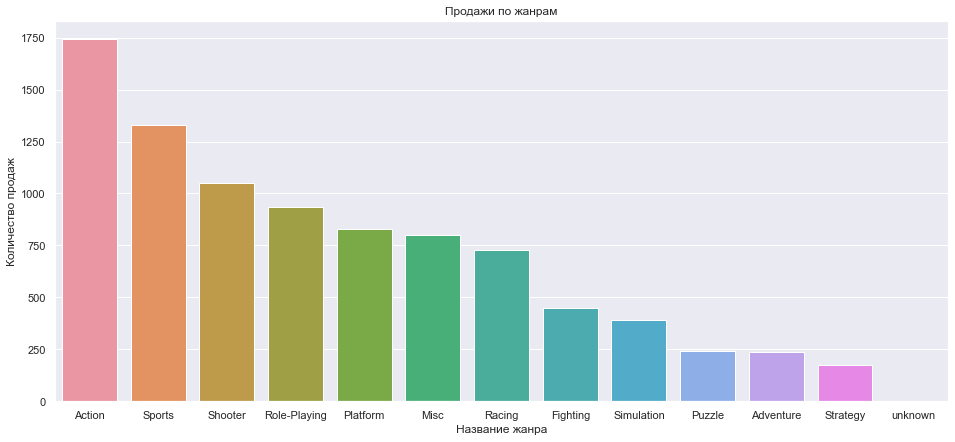

In [35]:
#продажи по жанрам за все время
sales_by_genre = df.pivot_table(index='genre', values='total_sales', aggfunc='sum').sort_values(
    by='total_sales', ascending=False)

plt.figure(figsize=(16,7))
sns.barplot(x=sales_by_genre.index, y=sales_by_genre['total_sales'])
plt.title("Продажи по жанрам")
plt.xlabel("Название жанра")
plt.ylabel("Количество продаж")

Text(0, 0.5, 'Количество продаж')

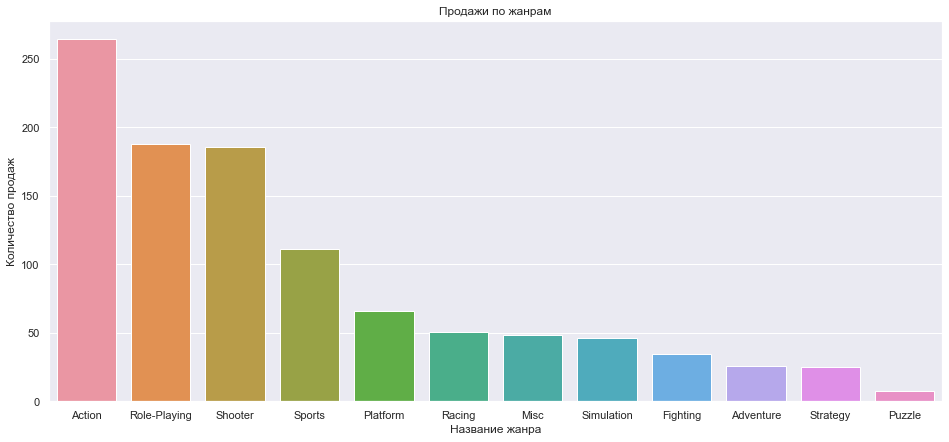

In [36]:
#продажи по жанрам после 2005
sales_by_genre = df_platform_after_2005.pivot_table(index='genre', values='total_sales', aggfunc='sum').sort_values(
    by='total_sales', ascending=False)

plt.figure(figsize=(16,7))
sns.barplot(x=sales_by_genre.index, y=sales_by_genre['total_sales'])
plt.title("Продажи по жанрам")
plt.xlabel("Название жанра")
plt.ylabel("Количество продаж")

Text(129.5, 0.5, 'Платформы')

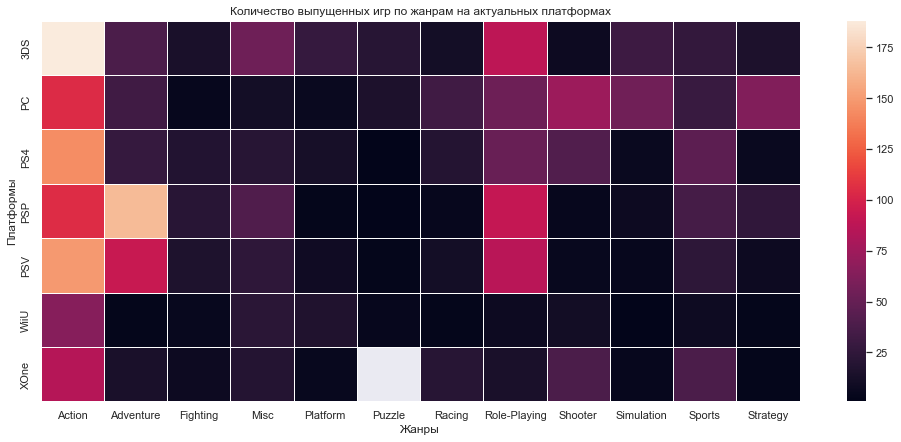

In [37]:
df_heatmap=df_platform_after_2005.pivot_table(index="platform",columns='genre',values='name',
                             aggfunc = {'name':'count'})
f, ax = plt.subplots(figsize=(17,7))
sns.set_theme()
sns.heatmap(df_heatmap, linewidths=.5)
plt.title("Количество выпущенных игр по жанрам на актуальных платформах")
plt.xlabel("Жанры")
plt.ylabel("Платформы")

<AxesSubplot:xlabel='platform'>

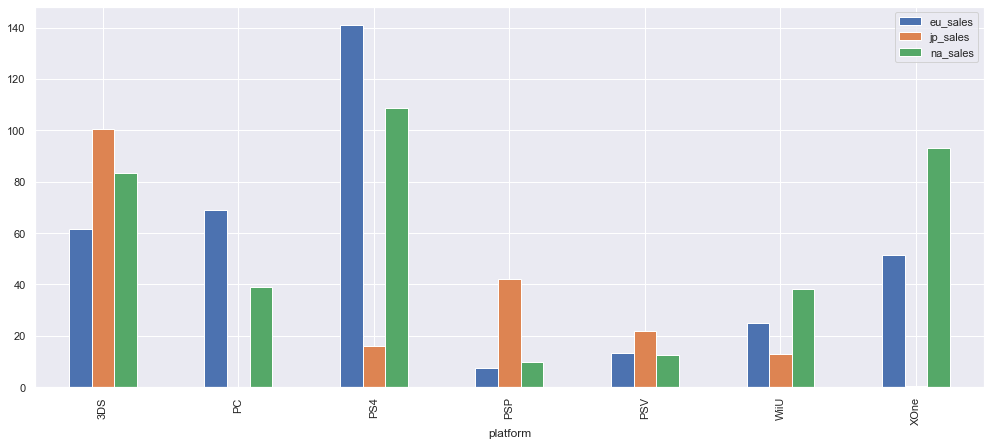

In [38]:
df_by_area_plot = df_platform_after_2005.pivot_table(index='platform',
                                                     values=['na_sales',
                                                    'eu_sales', 'jp_sales'],aggfunc=('sum'))
df_by_area_plot.plot(kind="bar", figsize=(17,7))

 - Самые популярные игры в жанрах Action, RPG, Shooter и Sport
 - С 2005 года RPG игры стали лучше продаваться
 - Самое большое колличество игр выпушено в жанрах Action, RPG, Adventure

## Шаг 4. Составьте портрет пользователя каждого региона

In [39]:
#сделаем срез продаж по платформах в разных регионах
df_by_area=df.pivot_table(index='platform',values=['na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'total_sales'],aggfunc=('sum'))
df_by_area=df_by_area.sort_values(by='total_sales',ascending=False).head(10)
df_by_area

,eu_sales,jp_sales,na_sales,other_sales,total_sales
platform,,,,,
PS2,339.29,139.20,583.84,193.44,1255.77
X360,270.76,12.43,602.47,85.76,971.42
PS3,330.29,80.19,393.49,135.68,939.65
Wii,262.21,69.33,496.90,79.07,907.51
DS,188.89,175.57,382.40,59.26,806.12
PS,213.61,139.82,336.52,40.91,730.86
GBA,75.25,47.33,187.54,7.73,317.85
PS4,141.09,15.96,108.74,48.35,314.14
PSP,66.68,76.78,109.17,41.42,294.05


In [40]:
#сравним с показателями последних 10 лет
df_by_area=df_platform_after_2005.pivot_table(index='platform',values=['na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'total_sales'],aggfunc=('sum'))
df_by_area=df_by_area.sort_values(by='total_sales',ascending=False).head(10)
df_by_area

,eu_sales,jp_sales,na_sales,other_sales,total_sales
platform,,,,,
PS4,141.09,15.96,108.74,48.35,314.14
3DS,61.48,100.67,83.49,13.36,259.00
XOne,51.59,0.34,93.12,14.27,159.32
PC,68.82,0.00,39.07,14.07,121.96
WiiU,25.13,13.01,38.10,5.95,82.19
PSP,7.59,42.20,9.65,4.61,64.05
PSV,13.12,21.91,12.58,6.46,54.07


 - Основные отличия между регионами по платформам: 
   - в Японии портативные консоли заметно популярнее чем в других регионах
   - в Японии не популярны изры на ПК и зарубежных консолях (XBOX)
   - Северная Америка и Европа сходятся в предпочтениях
   

In [41]:
#сделаем срез продаж по жанрам в разных регионах
df_by_area=df.pivot_table(index='genre',values=['na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'total_sales'],aggfunc=('sum'))
df_by_area=df_by_area.sort_values(by='total_sales',ascending=False).head(5)
df_by_area

,eu_sales,jp_sales,na_sales,other_sales,total_sales
genre,,,,,
Action,519.13,161.43,879.01,184.60,1744.17
Sports,376.79,135.54,684.43,134.51,1331.27
Shooter,317.34,38.76,592.24,104.11,1052.45
Role-Playing,188.71,355.41,330.81,59.63,934.56
Platform,200.35,130.83,445.50,51.09,827.77


In [42]:
#сравним с продажами с 2005 года
df_by_area=df_platform_after_2005.pivot_table(index='genre',values=['na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'total_sales'],aggfunc=('sum'))
df_by_area=df_by_area.sort_values(by='total_sales',ascending=False).head(5)
df_by_area

,eu_sales,jp_sales,na_sales,other_sales,total_sales
genre,,,,,
Action,94.10,44.69,97.37,28.52,264.68
Role-Playing,45.87,70.84,57.41,13.52,187.64
Shooter,74.61,5.13,82.69,23.60,186.03
Sports,46.97,7.56,41.96,14.73,111.22
Platform,22.47,10.74,27.17,5.67,66.05


<AxesSubplot:xlabel='genre'>

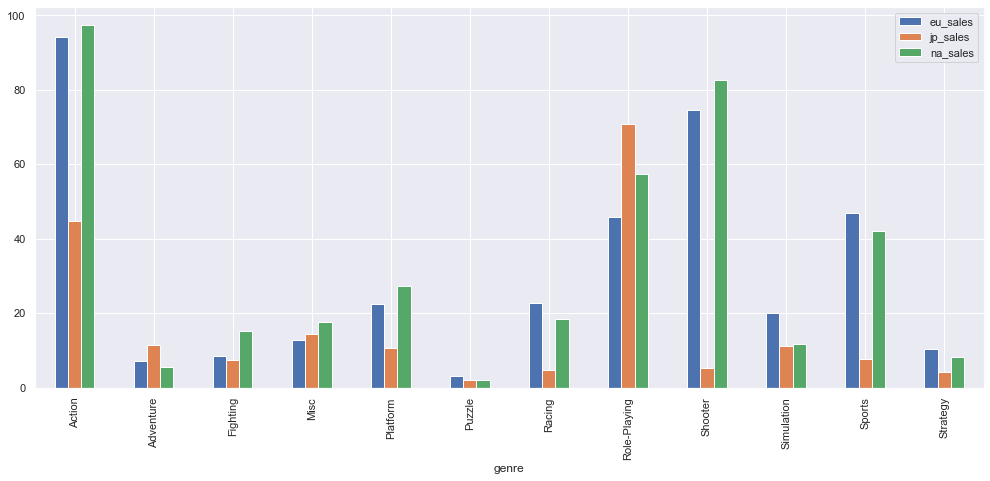

In [43]:
#сделаем более наглядную инфографику по продажам жанров в разных регионах с 2005
df_by_area_plot = df_platform_after_2005.pivot_table(index='genre',
                                                     values=['na_sales',
                                                    'eu_sales', 'jp_sales'],aggfunc=('sum'))
df_by_area_plot.plot(kind="bar", figsize=(17,7))


 - Основные отличия между регионами по жанрам: 
   - в Японии RPG игры заметно популярнее чем в других регионах
   - в Японии менее популярны игры в жанрах Sport, Shooter, Action, Racing (скорее всего из-за распространения портативных консолей, для которых выпускаются отдельные игры)
   - Северная Америка и Европа сходятся в предпочтениях почти во всем
   

In [44]:
df_by_rating=df.pivot_table(index='rating',values=['na_sales', 'eu_sales',
                                                   'jp_sales', 'other_sales',
                                                   'total_sales'],aggfunc=('sum'))
df_by_rating=df_by_rating.sort_values(by='total_sales',ascending=False)
df_by_rating

,eu_sales,jp_sales,na_sales,other_sales,total_sales
rating,,,,,
E,710.25,198.11,1292.99,234.17,2435.52
T,427.03,151.40,759.75,155.17,1493.35
M,483.97,64.24,748.48,177.10,1473.79
E10+,188.52,40.20,353.32,73.56,655.60
K-A,0.27,1.46,2.56,0.03,4.32
AO,0.61,0.00,1.26,0.09,1.96
EC,0.11,0.00,1.53,0.11,1.75
RP,0.08,0.00,0.00,0.01,0.09


In [45]:
df_by_rating=df_platform_after_2005.pivot_table(index=['name', 'platform',
                                   'genre', 'year_of_release', 'rating',
                                    'critic_score', 'user_score'],
                            values=['jp_sales','total_sales'],aggfunc=('sum'))
df_by_rating=df_by_rating.sort_values(by='jp_sales',ascending=False).head()
df_by_rating

,,,,,,,jp_sales,total_sales
name,platform,genre,year_of_release,rating,critic_score,user_score,,
Animal Crossing: New Leaf,3DS,Simulation,2012,E,88.0,8.7,4.39,9.17
Mario Kart 7,3DS,Racing,2011,E,85.0,8.2,2.69,12.65
Monster Hunter 4 Ultimate,3DS,Role-Playing,2014,T,86.0,8.7,2.62,3.89
New Super Mario Bros. 2,3DS,Platform,2012,E,78.0,7.2,2.47,9.90
Super Mario 3D Land,3DS,Platform,2011,E,90.0,8.4,2.14,10.81


In [46]:
df_by_rating=df_platform_after_2005.pivot_table(index=['name', 'platform',
                                   'genre', 'year_of_release', 'rating',
                                    'critic_score', 'user_score']
                                    ,values=['na_sales', 'total_sales'],aggfunc=('sum'))
df_by_rating=df_by_rating.sort_values(by='na_sales',ascending=False).head()
df_by_rating

,,,,,,,na_sales,total_sales
name,platform,genre,year_of_release,rating,critic_score,user_score,,
Mario Kart 7,3DS,Racing,2011,E,85.0,8.2,5.03,12.65
Super Mario 3D Land,3DS,Platform,2011,E,90.0,8.4,4.89,10.81
Grand Theft Auto V,PS4,Action,2014,M,97.0,8.3,3.96,12.62
New Super Mario Bros. 2,3DS,Platform,2012,E,78.0,7.2,3.66,9.90
Call of Duty: Advanced Warfare,XOne,Shooter,2014,M,81.0,5.4,3.22,5.26


In [47]:
df_by_rating=df_platform_after_2005.pivot_table(index=['name', 'platform',
                                   'genre', 'year_of_release', 'rating',
                                    'critic_score', 'user_score'],
                                    values=['eu_sales','total_sales'],aggfunc=('sum'))
df_by_rating=df_by_rating.sort_values(by='eu_sales',ascending=False).head()
df_by_rating

,,,,,,,eu_sales,total_sales
name,platform,genre,year_of_release,rating,critic_score,user_score,,
Grand Theft Auto V,PS4,Action,2014,M,97.0,8.3,6.31,12.62
FIFA 16,PS4,Sports,2015,E,82.0,4.3,6.12,8.58
FIFA 17,PS4,Sports,2016,E,85.0,5.0,5.75,7.60
FIFA 15,PS4,Sports,2014,E,82.0,5.7,4.33,6.08
Mario Kart 7,3DS,Racing,2011,E,85.0,8.2,4.02,12.65


Итог:
   - Для всех пользователей самыми популярными по возрастным ограничениям 
     являются игры с рейтингом до 18 лет, но так же и игры 18+ тоже популярны.
   - Лучше всего будут продаваться игры в которые могут играть все и дети до 18 
   - Пользователи предпочтут игру с высокими оценками пользователей и критиков
   - Самыми актальными жанрами будут Action, Sport, Shooter, Role-Playing, так же не стоит забывать Platform
     игры, которые выпускают до сих пор.
   - Стоит сконцентрироваться на актуальных платформах '3DS','PS4','XOne' и 'Wii', но возможно появление новых
   - Стоит обратить внимание на популярные ежегодные серии игр (прим. FIFA)
   

In [48]:
df

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.000000,8.000000,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,76.253975,7.349420,NaN,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.000000,8.300000,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.000000,8.000000,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,72.072883,7.359104,NaN,31.38
...,...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,64.979253,6.801914,NaN,0.01
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,64.979253,6.801914,NaN,0.01
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,64.979253,6.801914,NaN,0.01
16713,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,64.979253,6.801914,NaN,0.01


## Шаг 5

In [49]:
df_x_one=df.query('platform == "XOne"')

In [50]:
df_pc=df.query('platform == "PC"')

In [55]:
df_pc['critic_score'].isnull().sum()

0

In [56]:
df_x_one['critic_score'].isnull().sum()

0

In [57]:
#Гипотеза 1. Средние пользовательские рейтинги платформ Xbox One и PC одинаковые 
# H0 - Средние пользовательские рейтинги равны, Н1 - Средние пользовательские рейтинги не равны

xone_ttest = df_x_one['critic_score']

pc_ttest = df_pc['critic_score']

alpha = .05

results = st.ttest_ind(xone_ttest, pc_ttest, equal_var=False)

print('p-значение:', results.pvalue)

if results.pvalue < alpha:
    print("Средние пользовательские рейтинги не равны")
else:
    print("Средние пользовательские рейтинги равны")

p-значение: 0.006816065726278976
Средние пользовательские рейтинги не равны


Средние пользовательские рейтинги жанров Action (англ. «действие», экшен-игры) и Sports (англ. «спортивные соревнования») разные.

In [53]:
df_action=df.query('genre == "Action"')
df_sports=df.query('genre == "Sports"')

In [54]:
#Гипотеза 2. Средние пользовательские рейтинги жанров Action (англ. «действие», экшен-игры) 
#и Sports (англ. «спортивные соревнования») разные. 
# H0 - Средние пользовательские рейтинги разные, Н1 - Средние пользовательские рейтинги одинаковые

action_ttest = df_action['user_score']

sports_ttest = df_sports['user_score']

alpha = .05

results = st.ttest_ind(action_ttest, sports_ttest, equal_var=False)

print('p-значение:', results.pvalue)

if results.pvalue < alpha:
    print("Средние пользовательские рейтинги одинаковые")
else:
    print("Средние пользовательские рейтинги разные")

p-значение: 0.24325665259279866
Средние пользовательские рейтинги разные
